In [290]:
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt


In [291]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\delhi_uber_dataset.csv")

In [292]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2025-09-23,21:25:15,UBR197645,Driver Cancelled,cust23444,Uber Auto,Lajpat Nagar,Noida Sector 62,2.2,-,NaN,Yes,Too far,NO,NaN,NaN,16.5,NaN,NaN,Credit Card
1,2025-10-13,16:36:45,UBR140756,Completed,CUST65862,Uber Go,Aerocity,Vasant Kunj,3.8,29.1,NaN,NO,NaN,NO,NaN,511.6,25.9,3.7,4.6,Unknown
2,11-03-2025,NaN,UBR152026,Completed,CUST72140,Moto,Faridabad,Greater Kailash,90.0,49.9,NaN,NO,NaN,NO,NaN,135.8,5.7,4.4,4.7,Debit Card
3,NaN,16:59:32,UBR109526,Incomplete,CUST67783,Uber Auto,Ghaziabad,Saket,8.4,23.3,NaN,NO,NaN,Yes,NaN,NaN,10.8,NaN,NaN,upi
4,2025-07-16,23:36:10,UBR170351,Completed,CUST24921,uber xl,Faridabad,Rohini,5.4,16.9,NaN,No,NaN,No,NaN,121.3,3.3,5.0,4.6,debit card


In [293]:
df.shape


(100000, 20)

In [294]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Date                               95976 non-null  str  
 1   Time                               96728 non-null  str  
 2   Booking ID                         99702 non-null  str  
 3   Booking Status                     98678 non-null  str  
 4   Customer ID                        95074 non-null  str  
 5   Vehicle Type                       95987 non-null  str  
 6   Pickup Location                    96643 non-null  str  
 7   Drop Location                      96594 non-null  str  
 8   Avg VTAT                           93996 non-null  str  
 9   Avg CTAT                           90680 non-null  str  
 10  Reason for cancelling by Customer  12210 non-null  str  
 11  Cancelled Rides by Driver          96703 non-null  str  
 12  Driver Cancellation Reason  

In [295]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    errors="coerce"
)


In [296]:
df["Date"].dtype

dtype('<M8[us]')

In [297]:
df.duplicated().sum()

np.int64(674)

In [298]:
df = df.drop_duplicates()

In [299]:
df["Booking ID"].isnull().sum()
df = df.dropna(subset=["Booking ID"])

In [300]:
df["Customer ID"].isnull().sum()

np.int64(4883)

In [301]:
df['Avg CTAT'].unique()
#Not Available
#Unknown
#nan

<StringArray>
[   '-', '29.1', '49.9', '23.3', '16.9', '48.2', '44.5',    nan, '60.0',
 '42.9',
 ...
  '7.6', '11.1', '13.0',  '5.9',  '9.4',  '8.2',  '9.9', '10.3',  '6.9',
  '5.2']
Length: 562, dtype: str

In [302]:
df["Avg CTAT"]=df["Avg CTAT"].replace(["Not Available","Unknown",'-'],np.nan)
df["Avg CTAT"]=df["Avg CTAT"].astype(float)
#Not Available
#Unknown
#nan

<Axes: ylabel='Avg CTAT'>

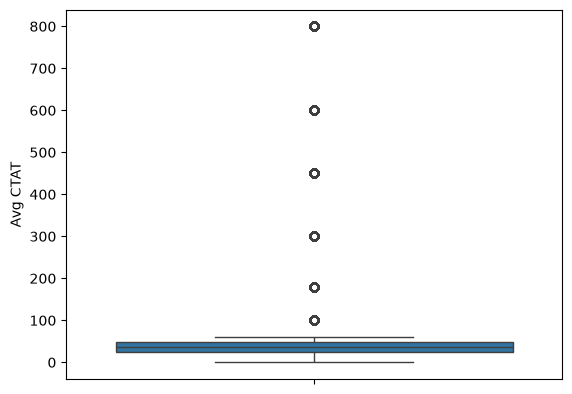

In [303]:
sns.boxplot(df["Avg CTAT"])

In [304]:
df["Avg CTAT"].describe()


count    85191.000000
mean        41.543061
std         51.908557
min          0.000000
25%         24.800000
50%         37.200000
75%         49.600000
max        800.000000
Name: Avg CTAT, dtype: float64

In [305]:
#iqr=75%-25%
iqr= 49.600000-  24.800000
upper_limit=49.600000 +1.5*iqr
lower_limit=  24.800000 -1.5*iqr
print(upper_limit)
print(lower_limit)

86.80000000000001
-12.400000000000002


Trimming

In [306]:
df[df["Avg CTAT"]>upper_limit]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
122,2025-11-18,16:30:17,UBR180044,Completed,CUST32543,Bike,Saket,Dwarka,NaN,600.0,NaN,No,NaN,No,NaN,NaN,13.0,4.8,5.0,Credit Card
355,2025-07-15,7:41 PM,UBR171349,COMPLETED,CUST35008,Uber Auto,Vasant Kunj,Aerocity,NaN,180.0,NaN,No,NaN,No,NaN,742,22.4,4.2,4.6,NaN
407,2025-05-06,06:18:57,UBR160355,Incomplete,CUST47924,Uber XL,noida sector 62,Kaushambi,3.5,300.0,NaN,No,NaN,Yes,NaN,Not Available,5.2,NaN,NaN,Credit Card
517,2025-04-28,04:57:23,UBR108192,Driver Cancelled,CUST48109,Premier,Rajouri Garden,Anand Vihar,1.0,800.0,NaN,Yes,Customer not reachable,No,NaN,753.3,unknown,NaN,NaN,upi
602,2025-05-05,17:54:54,UBR197371,Completed,CUST51512,moto,Ghaziabad,Connaught Place,7.3,450.0,NaN,No,NaN,No,NaN,184.5,8.2,4.7,Not Available,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99860,2025-02-27,08:08:35,UBR122856,Driver Cancelled,CUST36530,Bike,DLF Phase 1,IGI Airport,14.8,100.0,NaN,yes,Other,Unknown,NaN,NaN,21.2,NaN,NaN,UPI
99885,2025-02-22,00:34:51,ubr181311,Completed,CUST52225,Uber XL,Aerocity,Dwarka,2.3,180.0,NaN,No,NaN,No,NaN,122.6,5.3,4.9,4.1,Debit Card
99905,2025-04-14,01:09:47,UBR157929,COMPLETED,CUST33698,UberAuto,NaN,Not Available,8.7,180.0,NaN,NO,NaN,no,NaN,320.0,15.9,4.3,4.3,CASH
99937,2025-02-18,7:08 PM,UBR146694,Customer Cancelled,CUST48683,Uber Go,New Delhi Railway Station,Lajpat Nagar,NaN,800.0,Driver not moving,no,NaN,No,NaN,76.7,4.0,NaN,NaN,upi


In [307]:
df[df["Avg CTAT"]<lower_limit]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


In [308]:
df[df["Avg CTAT"] > 100]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
122,2025-11-18,16:30:17,UBR180044,Completed,CUST32543,Bike,Saket,Dwarka,NaN,600.0,NaN,No,NaN,No,NaN,NaN,13.0,4.8,5.0,Credit Card
355,2025-07-15,7:41 PM,UBR171349,COMPLETED,CUST35008,Uber Auto,Vasant Kunj,Aerocity,NaN,180.0,NaN,No,NaN,No,NaN,742,22.4,4.2,4.6,NaN
407,2025-05-06,06:18:57,UBR160355,Incomplete,CUST47924,Uber XL,noida sector 62,Kaushambi,3.5,300.0,NaN,No,NaN,Yes,NaN,Not Available,5.2,NaN,NaN,Credit Card
517,2025-04-28,04:57:23,UBR108192,Driver Cancelled,CUST48109,Premier,Rajouri Garden,Anand Vihar,1.0,800.0,NaN,Yes,Customer not reachable,No,NaN,753.3,unknown,NaN,NaN,upi
602,2025-05-05,17:54:54,UBR197371,Completed,CUST51512,moto,Ghaziabad,Connaught Place,7.3,450.0,NaN,No,NaN,No,NaN,184.5,8.2,4.7,Not Available,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99803,2025-08-09,13:53:25,UBR166612,Completed,CUST26058,Uber Go,Saket,Dwarka,2.2,800.0,NaN,no,NaN,Unknown,NaN,105.6,6.5,4.3,4.8,wallet
99820,2025-08-30,15:30:04,UBR156869,Driver Cancelled,CUST66255,Uber GO,Indirapuram,NaN,6.5,800.0,NaN,YES,Too far,no,NaN,234.2,NaN,NaN,NaN,UPI
99885,2025-02-22,00:34:51,ubr181311,Completed,CUST52225,Uber XL,Aerocity,Dwarka,2.3,180.0,NaN,No,NaN,No,NaN,122.6,5.3,4.9,4.1,Debit Card
99905,2025-04-14,01:09:47,UBR157929,COMPLETED,CUST33698,UberAuto,NaN,Not Available,8.7,180.0,NaN,NO,NaN,no,NaN,320.0,15.9,4.3,4.3,CASH


In [309]:
new_df=df[df["Avg CTAT"]<upper_limit]

In [310]:
new_df.shape

(84100, 20)

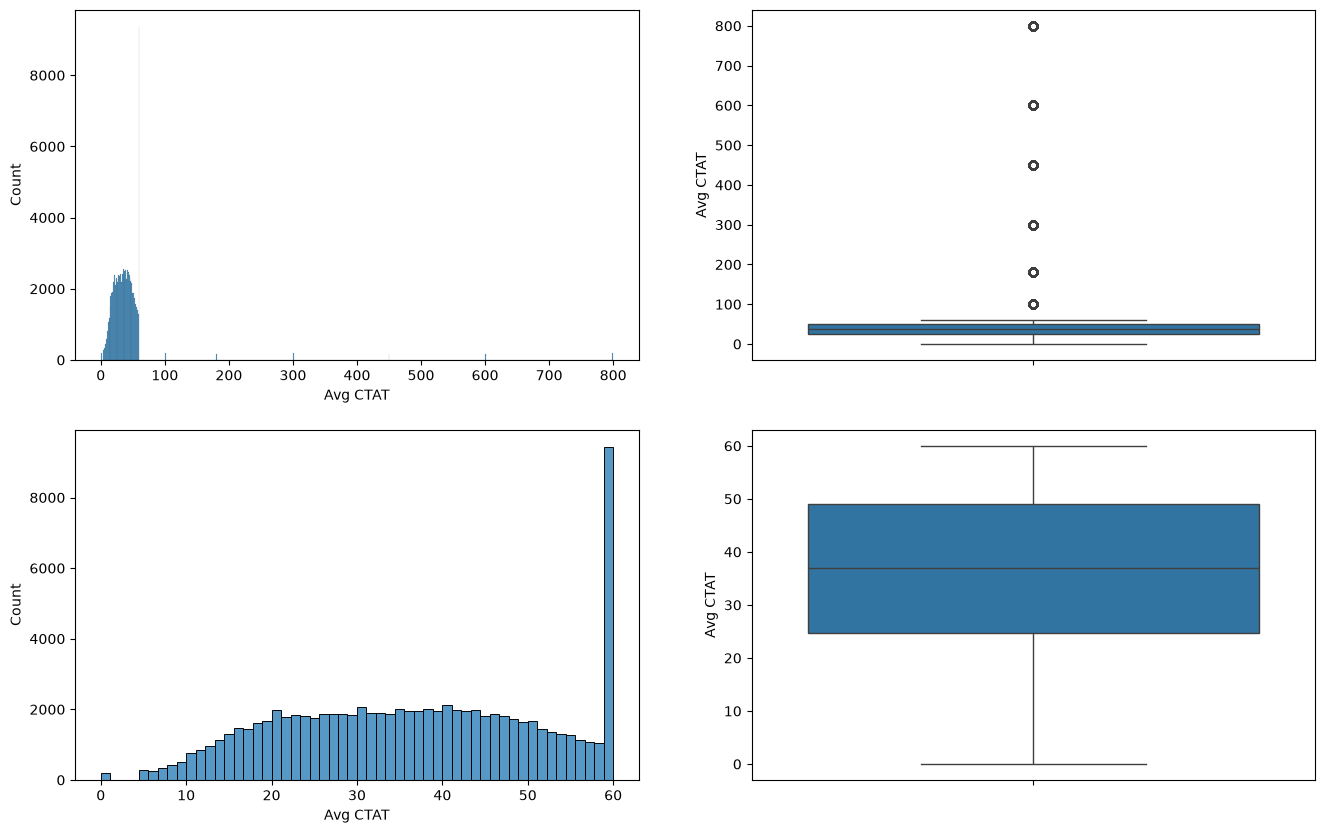

In [311]:
#Compairing
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.histplot(df["Avg CTAT"])

plt.subplot(2, 2, 2)
sns.boxplot(df["Avg CTAT"])

plt.subplot(2, 2, 3)
sns.histplot(new_df["Avg CTAT"])

plt.subplot(2, 2, 4)
sns.boxplot(new_df["Avg CTAT"])

plt.show()

In [312]:
df = new_df.copy()

In [313]:
df["Avg CTAT"] = df["Avg CTAT"].fillna(df["Avg CTAT"].mean())


In [314]:
df["Avg VTAT"]=df["Avg VTAT"].replace(["Not Available","Unknown",'-'],np.nan)
df["Avg VTAT"]=df["Avg VTAT"].astype(float)

<Axes: ylabel='Avg VTAT'>

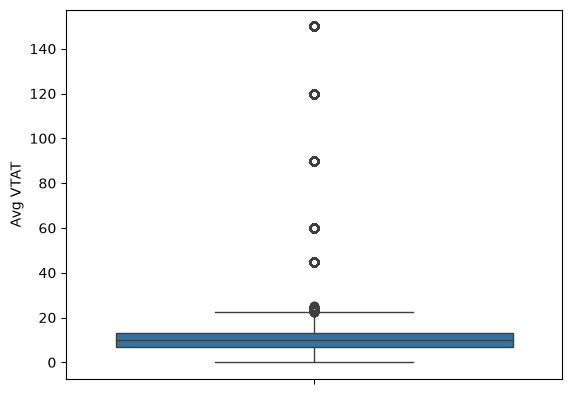

In [315]:
sns.boxplot(df["Avg VTAT"])

In [316]:
df["Avg VTAT"].describe()

count    76550.000000
mean        11.008579
std         10.749906
min          0.000000
25%          7.000000
50%         10.000000
75%         13.200000
max        150.000000
Name: Avg VTAT, dtype: float64

In [317]:
#iqr=75%-25%
iqr=    13.200000-  7.000000
upper_limit=13.200000 +1.5*iqr
lower_limit=  7.000000 -1.5*iqr
print(upper_limit)
print(lower_limit)

22.5
-2.299999999999999


In [318]:
df[df["Avg VTAT"]>upper_limit]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
2,2025-11-03,NaN,UBR152026,Completed,CUST72140,Moto,Faridabad,Greater Kailash,90.0,49.9,NaN,NO,NaN,NO,NaN,135.8,5.7,4.4,4.7,Debit Card
162,2025-04-19,17:48:13,UBR174260,Completed,CUST21788,Uber XL,Hauz Khas,Janakpuri,60.0,37.3,NaN,No,NaN,NO,NaN,397.4,11.7,4.3,-,wallet
384,2025-01-17,10:48:44,UBR113046,Customer Cancelled,CUST28296,Bike,noida sector 18,New Delhi Railway Station,120.0,25.7,Other,no,NaN,no,NaN,299.4,NaN,NaN,NaN,upi
482,2025-09-06,19:52:08,UBR116093,Completed,CUST61587,Uber Go,Connaught Place,Rohini,120.0,45.7,NaN,NO,NaN,No,NaN,318.9,8.6,NaN,NaN,UPI
496,2025-07-21,NaN,UBR186756,Completed,CUST57981,Uber Auto,Janakpuri,NaN,150.0,17.0,NaN,No,NaN,NO,NaN,166.7,7.4,4.0,5.0,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99251,2025-04-20,7:09 AM,UBR900480,Completed,CUST65017,UberAuto,Hauz Khas,Gurugram,60.0,34.4,NaN,no,NaN,No,NaN,295.3,9.1,Not Available,4.4,Credit Card
99601,2025-11-07,11:33 AM,UBR128446,Completed,Not Available,Unknown,Greater Kailash,Kashmere Gate,90.0,17.7,NaN,NO,NaN,no,NaN,439.6,17.8,4.6,4.6,UPI
99639,2025-10-03,08:25:40,UBR174077,incomplete,CUST59045,Uber Premier,Vaishali,Cyber City,45.0,40.8,NaN,No,NaN,yes,Route issue,NaN,3.8,NaN,3.5,Debit Card
99683,2025-11-29,5:38 PM,UBR189991,Completed,CUST74872,Uber Auto,Not Available,Aerocity,60.0,41.3,NaN,No,NaN,No,NaN,1304.0,37.5,5.0,4.7,Unknown


In [319]:
new_df=df[df["Avg VTAT"]<upper_limit]

In [320]:
new_df.shape

(75574, 20)

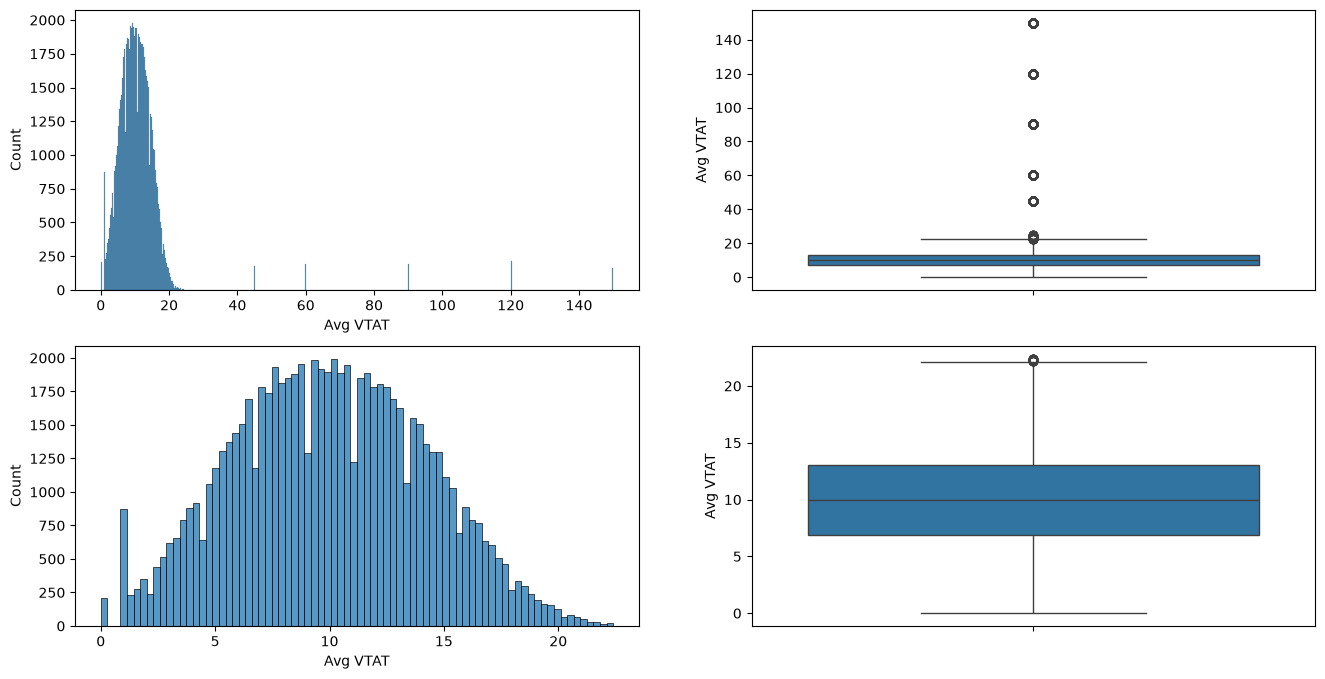

In [321]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df["Avg VTAT"])

plt.subplot(2, 2, 2)
sns.boxplot(df["Avg VTAT"])

plt.subplot(2, 2, 3)
sns.histplot(new_df["Avg VTAT"])

plt.subplot(2, 2, 4)
sns.boxplot(new_df["Avg VTAT"])

plt.show()

In [322]:
df = new_df.copy()

In [323]:
df["Avg VTAT"] = df["Avg VTAT"].fillna(df["Avg VTAT"].mean())


In [324]:
df["Cancelled Rides by Driver"] = df["Cancelled Rides by Driver"].str.strip().str.title()
df["Cancelled Rides by Driver"].unique()
#yes , Yes , YES Unknown nan - Not avaialable
#no No NO 

<StringArray>
['No', 'Yes', 'Unknown', nan, '-', 'Not Available']
Length: 6, dtype: str

In [325]:
df["Cancelled Rides by Driver"] =df["Cancelled Rides by Driver"].replace(["Unknown","-","Not Available"],np.nan)


In [326]:
df["Cancelled Rides by Driver"]=df["Cancelled Rides by Driver"].fillna("Unknown")

In [327]:
df["Cancelled Rides by Driver"].isnull().sum()


np.int64(0)

In [328]:
df["Booking Status"].unique()

<StringArray>
[         'Completed',         'Incomplete',         'Completed ',
   'Driver Cancelled', 'Customer Cancelled',          'COMPLETED',
                  nan,          'completed', 'CUSTOMER CANCELLED',
          'Cancelled',   'driver cancelled',        'Incomplete ',
      'Not Available',         'INCOMPLETE',                  '-',
 'customer cancelled',         'incomplete',            'Unknown',
   'DRIVER CANCELLED']
Length: 19, dtype: str

In [329]:
df['Booking Status'] =df['Booking Status'].replace(["Unknown","-","Not Available"],np.nan)
df['Booking Status'] =df['Booking Status'].replace(['Driver Cancelled','driver cancelled','DRIVER CANCELLED'],'driver cancelled')
df['Booking Status'] =df['Booking Status'].replace(['Completed','COMPLETED'],'completed')
df['Booking Status'] =df['Booking Status'].replace(['Customer Cancelled','CUSTOMER CANCELLED','customer cancelled','Cancelled'],np.nan)
df['Booking Status'] =df['Booking Status'].replace([],np.nan)

df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
1,2025-10-13,16:36:45,UBR140756,completed,CUST65862,Uber Go,Aerocity,Vasant Kunj,3.8,29.1,NaN,No,NaN,NO,NaN,511.6,25.9,3.7,4.6,Unknown
3,NaT,16:59:32,UBR109526,Incomplete,CUST67783,Uber Auto,Ghaziabad,Saket,8.4,23.3,NaN,No,NaN,Yes,NaN,NaN,10.8,NaN,NaN,upi
4,2025-07-16,23:36:10,UBR170351,Completed,CUST24921,uber xl,Faridabad,Rohini,5.4,16.9,NaN,No,NaN,No,NaN,121.3,3.3,5.0,4.6,debit card
5,2025-02-14,08:26:31,UBR159524,completed,CUST60675,Moto,Anand Vihar,Janakpuri,11.4,48.2,NaN,No,NaN,No,NaN,317.2,8.7,5.0,4.6,Wallet
6,2025-03-20,10:08:01,UBR177856,driver cancelled,CUST63386,Bike,Vasant Kunj,DLF Phase 1,10.5,44.5,NaN,Yes,Vehicle issue,No,NaN,NaN,5.5,NaN,NaN,Wallet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,2025-09-13,07:21:14,UBR158286,completed,CUST63626,Uber Auto,Indirapuram,Janakpuri,10.6,41.7,NaN,No,NaN,NaN,NaN,281.4,7.3,5.0,5.0,NaN
99995,2025-03-03,NaN,UBR193256,Incomplete,CUST56008,Moto,Kaushambi,Vasant Kunj,13.6,39.6,NaN,No,NaN,Yes,technical issue,147.3,NaN,NaN,5.5,UPI
99996,2025-10-13,04:58:01,UBR108482,completed,CUST46241,Uber Go,Hauz Khas,Anand Vihar,4.8,11.0,NaN,No,NaN,no,NaN,124.4,4.5,5.5,4.3,Credit Card
99997,2025-05-04,18:25:24,UBR121921,Incomplete,CUST34007,Uber Go,new delhi,Anand Vihar,9.9,42.8,NaN,No,NaN,YES,other,345.8,12.9,4.9,4.9,UPI


In [330]:
df.describe()

,Date,Avg VTAT,Avg CTAT
count,72160,75574.000000,75574.000000
mean,2025-07-01 20:31:25.410199,10.001100,36.850734
min,2025-01-01 00:00:00,0.000000,0.000000
25%,2025-04-02 00:00:00,6.900000,24.700000
50%,2025-07-02 00:00:00,10.000000,36.900000
75%,2025-10-01 00:00:00,13.000000,49.000000
max,2025-12-31 00:00:00,22.400000,60.000000
std,NaN,4.183256,15.019645


In [331]:
df.dtypes

Date                                 datetime64[us]
Time                                            str
Booking ID                                      str
Booking Status                                  str
Customer ID                                     str
Vehicle Type                                    str
Pickup Location                                 str
Drop Location                                   str
Avg VTAT                                    float64
Avg CTAT                                    float64
Reason for cancelling by Customer               str
Cancelled Rides by Driver                       str
Driver Cancellation Reason                      str
Incomplete Rides                                str
Incomplete Rides Reason                         str
Booking Value                                   str
Ride Distance                                   str
Driver Ratings                                  str
Customer Rating                                 str
Payment Meth

In [332]:
df["Driver Cancellation Reason"].unique()

<StringArray>
[                        nan,             'Vehicle issue',
             'Not Available',                   'Traffic',
     'Wrong pickup location',                   'Unknown',
                   'Too far',                     'Other',
  'Customer asked to cancel',        'Personal emergency',
    'Customer not reachable',    'CUSTOMER NOT REACHABLE',
                         '-',             'vehicle issue',
                   'TOO FAR',    'customer not reachable',
 ' Customer asked to cancel',     'wrong pickup location',
            ' Vehicle issue',                    ' Other',
                   'TRAFFIC',   'Customer not reachable ',
                   'traffic',        'PERSONAL EMERGENCY',
    ' Wrong pickup location',  'customer asked to cancel',
                     'other',                    'Other ',
                   'too far',        'personal emergency',
                     'OTHER',     'WRONG PICKUP LOCATION',
                  ' Too far',             

In [333]:
df["Driver Cancellation Reason"]=df["Driver Cancellation Reason"].replace(["-","Not Available"],"Unknown")
df["Driver Cancellation Reason"]=df["Driver Cancellation Reason"].fillna("Unknown")

In [334]:
df.isnull().sum()

Date                                  3414
Time                                  2504
Booking ID                               0
Booking Status                        9997
Customer ID                           3707
Vehicle Type                          3046
Pickup Location                       2539
Drop Location                         2559
Avg VTAT                                 0
Avg CTAT                                 0
Reason for cancelling by Customer    66389
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                      2527
Incomplete Rides Reason              67663
Booking Value                        12138
Ride Distance                        13467
Driver Ratings                       25257
Customer Rating                      25120
Payment Method                        5777
dtype: int64

In [335]:
def uni(a):
    for i in a:
        print(i)

In [336]:
df["Booking Status"].unique()

<StringArray>
[       'completed',       'Incomplete',       'Completed ',
 'driver cancelled',                nan,      'Incomplete ',
       'INCOMPLETE',       'incomplete']
Length: 8, dtype: str

In [337]:
df["Booking Status"]=df["Booking Status"].replace(['Incomplete ','incomplete','INCOMPLETE'],'Incomplete')
df["Booking Status"]=df["Booking Status"].replace(['completed','Completed '],'Completed')
df["Booking Status"]=df["Booking Status"].replace(['driver cancelled'],'Driver cancelled')


In [338]:
df["Customer Rating"] = df["Customer Rating"].str.removesuffix(" stars")

In [339]:
df["Customer Rating"]=df["Customer Rating"].replace(["Unknown","Not Available","-"],np.nan)

In [340]:
df["Customer Rating"] = (
    df["Customer Rating"]
        .str.replace('"', '')
)

In [341]:
df["Customer Rating"] = df["Customer Rating"].astype(float)

In [342]:
df["Customer Rating"] = df["Customer Rating"].apply(lambda x: math.floor(x * 10) / 10 if pd.notna(x) else x)


In [343]:
df["Customer Rating"].isna().sum()
(df["Customer Rating"].isna().sum() / len(df)) * 100


np.float64(36.5906264059068)

In [451]:
df.loc[df["Customer Rating"]<0,"Customer Rating"]=np.nan

In [344]:
df.groupby("Booking Status")["Customer Rating"].agg(
    Total="size",
    Missing=lambda x: x.isna().sum(),
    Available="count"
)

,Total,Missing,Available
Booking Status,,,
Completed,51878,7009,44869
Driver cancelled,6321,6263,58
Incomplete,7378,5399,1979


In [345]:

avg_rating = df.loc[df["Booking Status"] == "Completed", "Customer Rating"].mean()
row = df["Booking Status"] == "Completed"

df.loc[row, "Customer Rating"] = (df.loc[row, "Customer Rating"].fillna(avg_rating))

In [346]:
for i in df["Driver Cancellation Reason"].unique():
    print(i)
    

Unknown
Vehicle issue
Traffic
Wrong pickup location
Too far
Other
Customer asked to cancel
Personal emergency
Customer not reachable
CUSTOMER NOT REACHABLE
vehicle issue
TOO FAR
customer not reachable
 Customer asked to cancel
wrong pickup location
 Vehicle issue
 Other
TRAFFIC
Customer not reachable 
traffic
PERSONAL EMERGENCY
 Wrong pickup location
customer asked to cancel
other
Other 
too far
personal emergency
OTHER
WRONG PICKUP LOCATION
 Too far
VEHICLE ISSUE
CUSTOMER ASKED TO CANCEL
 Traffic
Too far 
Vehicle issue 
 Personal emergency
Personal emergency 
 Customer not reachable
Wrong pickup location 
Traffic 
Customer asked to cancel 


In [347]:
df["Driver Cancellation Reason"]

1              Unknown
3              Unknown
4              Unknown
5              Unknown
6        Vehicle issue
             ...      
99994          Unknown
99995          Unknown
99996          Unknown
99997          Unknown
99999          Unknown
Name: Driver Cancellation Reason, Length: 75574, dtype: str

In [348]:
df["Driver Cancellation Reason"] = df["Driver Cancellation Reason"].str.strip().str.title()

In [349]:
df["Driver Cancellation Reason"] = df["Driver Cancellation Reason"].replace("Unknown","No reason Provided")


In [350]:
df["Drop Location"]=df["Drop Location"].str.strip().str.title()

In [351]:
df["Drop Location"] = (
    df["Drop Location"].replace({
        "new delhi": "Delhi",
        "New Delhi": "Delhi",
        "DELHI": "Delhi",
        "delhi": "Delhi",
        "Gurgaon": "Gurugram",
        "Connaught Plce": "Connaught Place",
        "Not Available": "Unknown",
        "-": "Unknown"
    })
)

In [352]:
df["Drop Location"].unique()

<StringArray>
[              'Vasant Kunj',                     'Saket',
                    'Rohini',                 'Janakpuri',
               'Dlf Phase 1',           'Greater Kailash',
                  'Gurugram', 'New Delhi Railway Station',
                 'Hauz Khas',               'Indirapuram',
           'Noida Sector 18',             'Kashmere Gate',
               'Igi Airport',                'Karol Bagh',
                     'Delhi',           'Noida Sector 62',
                  'Vaishali',                 'Ghaziabad',
                   'Mg Road',                    'Dwarka',
                'Cyber City',                  'Aerocity',
              'Lajpat Nagar',                         nan,
               'Anand Vihar',                 'Faridabad',
           'Connaught Place',                 'Kaushambi',
            'Rajouri Garden',                   'Unknown',
               'Rajouri Gdn']
Length: 31, dtype: str

In [353]:
df["Drop Location"].isnull().sum()

np.int64(2559)

In [354]:
df["Drop Location"]=df["Drop Location"].fillna("Unknown")

In [355]:
df["Drop Location"].value_counts()

Drop Location
Delhi                        4912
Unknown                      3759
Anand Vihar                  2592
Gurugram                     2556
Rohini                       2539
New Delhi Railway Station    2514
Kaushambi                    2506
Aerocity                     2495
Saket                        2492
Dlf Phase 1                  2491
Vasant Kunj                  2488
Hauz Khas                    2488
Janakpuri                    2487
Vaishali                     2484
Lajpat Nagar                 2484
Connaught Place              2480
Indirapuram                  2479
Greater Kailash              2478
Cyber City                   2473
Karol Bagh                   2471
Noida Sector 18              2467
Faridabad                    2459
Dwarka                       2454
Noida Sector 62              2452
Kashmere Gate                2425
Igi Airport                  2425
Ghaziabad                    2414
Mg Road                      2372
Rajouri Garden               2279


In [356]:
df["Incomplete Rides"].value_counts()

Incomplete Rides
No               16225
No               16153
no               16137
NO               16121
YES               1860
yes               1808
Yes               1795
Yes               1701
-                  431
Not Available      429
Unknown            387
Name: count, dtype: int64

In [357]:
df["Incomplete Rides"] = (
    df["Incomplete Rides"]
    .str.strip()
    .str.title()
    .replace(["-", "Unknown", "Not Available"], np.nan)
)

In [358]:
df.head(1)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
1,2025-10-13,16:36:45,UBR140756,Completed,CUST65862,Uber Go,Aerocity,Vasant Kunj,3.8,29.1,NaN,No,No reason Provided,No,NaN,511.6,25.9,3.7,4.6,Unknown


In [359]:
df["Incomplete Rides"]=df["Incomplete Rides"].str.strip().str.title()

In [360]:
df['Vehicle Type'].unique()

<StringArray>
[      'Uber Go',     'Uber Auto',       'uber xl',          'Moto',
          'Bike',        'UberXL',       'Uber XL',          'moto',
             nan,       'Uber GO',          'Auto',  'Uber Premier',
     'uber auto',      'UberAuto',  'uber premier',       'uber go',
        'UberGo', 'Not Available',       'Unknown',       'Premier',
            'Go',          'bike',             '-']
Length: 23, dtype: str

In [361]:
df['Vehicle Type']=df['Vehicle Type'].str.strip().str.title()

In [362]:
df["Vehicle Type"]=df["Vehicle Type"].replace(["Auto","Uberauto"],"Uber Auto")
df["Vehicle Type"]=df["Vehicle Type"].replace(["Go","Ubergo"],"Uber Go")
df["Vehicle Type"]=df["Vehicle Type"].replace(["Premier"],"Uber Premier")
df["Vehicle Type"]=df["Vehicle Type"].replace(["Uberxl"],"Uber Xl")
df["Vehicle Type"]=df["Vehicle Type"].replace("Moto","Bike")
# df["Vehicle Type"]=df["Vehicle Type"].replace([""])



In [363]:
df[["Vehicle Type","Incomplete Rides"]]

,Vehicle Type,Incomplete Rides
1,Uber Go,No
3,Uber Auto,Yes
4,Uber Xl,No
5,Bike,No
6,Bike,No
...,...,...
99994,Uber Auto,NaN
99995,Bike,Yes
99996,Uber Go,No
99997,Uber Go,Yes


In [364]:
df.loc[df["Vehicle Type"] == "Not Available", "Incomplete Rides"].value_counts()

Incomplete Rides
No     402
Yes     54
Name: count, dtype: int64

In [365]:
df["Vehicle Type"]=df["Vehicle Type"].replace("-","Unknown")

In [366]:
df["Incomplete Rides Reason"]=df["Incomplete Rides Reason"].str.strip().str.title()

In [367]:
df["Incomplete Rides Reason"]=df["Incomplete Rides Reason"].replace(["-","Not Available"],"Unknown")

In [368]:
df["Incomplete Rides Reason"].value_counts()

Incomplete Rides Reason
Unknown               2531
Route Issue            817
Trip Interrupted       800
Driver Emergency       799
Technical Issue        756
Customer Emergency     745
Other                  740
Vehicle Breakdown      723
Name: count, dtype: int64

In [369]:
df["Incomplete Rides Reason"].isna().sum()

np.int64(67663)

In [370]:
df["Incomplete Rides"].value_counts(dropna=False)

Incomplete Rides
No     64636
Yes     7164
NaN     3774
Name: count, dtype: int64

In [371]:
df["Incomplete Rides Reason"].value_counts(dropna=False)

Incomplete Rides Reason
NaN                   67663
Unknown                2531
Route Issue             817
Trip Interrupted        800
Driver Emergency        799
Technical Issue         756
Customer Emergency      745
Other                   740
Vehicle Breakdown       723
Name: count, dtype: int64

In [372]:
df["Payment Method"].value_counts()

Payment Method
UPI              21240
Cash             10070
Credit Card       8137
upi               6404
Debit Card        6118
Wallet            5193
Unknown           2477
debit card        1928
cash              1555
CASH              1515
wallet            1489
CreditCard        1200
credit card       1165
Not Available      686
-                  620
Name: count, dtype: int64

In [373]:
df["Payment Method"]=df["Payment Method"].str.strip().str.title()

In [374]:
df["Payment Method"]=df["Payment Method"].replace("Wallet","Cash")
df["Payment Method"]=df["Payment Method"].replace("Creditcard","Credit Card")
df["Payment Method"]=df["Payment Method"].replace("-","Unknown")

In [375]:
df["Pickup Location"].value_counts(dropna=False)

Pickup Location
Janakpuri                    2560
Kashmere Gate                2553
Greater Kailash              2547
Hauz Khas                    2545
IGI Airport                  2544
NaN                          2539
MG Road                      2526
Cyber City                   2507
Dwarka                       2506
Kaushambi                    2503
Indirapuram                  2490
Vasant Kunj                  2472
Faridabad                    2466
Saket                        2464
Anand Vihar                  2457
DLF Phase 1                  2455
New Delhi Railway Station    2453
Rohini                       2452
Vaishali                     2447
Noida Sector 62              2410
Karol Bagh                   2409
Aerocity                     2377
Ghaziabad                    2312
New Delhi                    2296
Noida Sector 18              2291
Lajpat Nagar                 2275
Rajouri Garden               2270
Delhi                        2255
Connaught Place              217

In [376]:
df["Pickup Location"]=df["Pickup Location"].str.strip().str.title()

In [377]:
df["Pickup Location"] = df["Pickup Location"].replace({
    "Gurgaon": "Gurugram",
    "Connaught Plce": "Connaught Place",
    "Delhi": "New Delhi",  
    "Rajouri Gdn": "Rajouri Garden",    
    "-": np.nan,
    "Not Available": np.nan,
    "Unknown": np.nan
})

In [378]:
df["Reason for cancelling by Customer"].value_counts(dropna=False)

Reason for cancelling by Customer
NaN                        66389
Not Available                861
-                            851
Unknown                      831
Wrong pickup location        737
Other                        734
Driver is too far            716
Driver not moving            716
Wait time too long           707
Change of plans              699
Driver asked to cancel       676
change of plans              110
driver asked to cancel       107
driver is too far            100
WRONG PICKUP LOCATION         95
wait time too long            92
OTHER                         87
other                         82
driver not moving             82
WAIT TIME TOO LONG            80
wrong pickup location         80
CHANGE OF PLANS               79
DRIVER NOT MOVING             74
DRIVER ASKED TO CANCEL        71
DRIVER IS TOO FAR             68
 Wait time too long           50
 Other                        39
 Change of plans              36
Driver is too far             34
 Driver a

In [379]:
df["Reason for cancelling by Customer"]=df["Reason for cancelling by Customer"].str.strip().str.title()

reason wasn't recorded

In [380]:
pd.crosstab(df["Booking Status"], df["Reason for cancelling by Customer"])

Reason for cancelling by Customer,-,Not Available,Unknown
Booking Status,,,
Completed,582,583,570
Driver cancelled,76,67,88
Incomplete,78,91,76


In [381]:
df["Reason for cancelling by Customer"] = df["Reason for cancelling by Customer"].replace({
    "-": np.nan,
    "Not Available": np.nan,
    "Unknown": np.nan
})

In [382]:
df["Reason for cancelling by Customer"].value_counts(dropna=False)

Reason for cancelling by Customer
NaN                       68932
Wrong Pickup Location       970
Other                       967
Wait Time Too Long          956
Change Of Plans             953
Driver Is Too Far           944
Driver Not Moving           934
Driver Asked To Cancel      918
Name: count, dtype: int64

In [383]:
df["Ride Distance"].value_counts(dropna=False)

Ride Distance
NaN                   13467
unknown                1165
-                       603
Not Available           589
Unknown                 582
                      ...  
12.057899041087012        1
3.4777334919106675        1
6.7102030954187715        1
12.666940528846903        1
16.456247491189004        1
Name: count, Length: 2325, dtype: int64

In [384]:
df["Ride Distance"]=df["Ride Distance"].str.strip().str.title()

In [385]:
df["Ride Distance"] = df["Ride Distance"].replace({
    "-": np.nan,
    'Not Available': np.nan,
    "Unknown": np.nan
})

In [386]:
df["Ride Distance"]=df["Ride Distance"].astype(float)


In [387]:
df["Ride Distance"] = df["Ride Distance"].apply(lambda x: math.floor(x * 10) / 10 if pd.notna(x) else x)

In [388]:
df["Ride Distance"].describe()

count    59168.000000
mean        14.144240
std         16.363868
min        -37.900000
25%          6.800000
50%         11.100000
75%         17.400000
max        250.000000
Name: Ride Distance, dtype: float64

In [389]:
(df["Ride Distance"] < 0).sum()

np.int64(48)

In [390]:
df[df["Ride Distance"] < 0]     

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
1392,2025-01-27,10:12:11,UBR168972,Completed,CUST23212,Bike,Lajpat Nagar,Rohini,12.5,39.8,NaN,No,No reason Provided,No,NaN,166.8,-5.6,5.0,4.600000,Upi
7132,2025-07-16,18:14:16,UBR114407,Completed,CUST74081,Uber Go,Dlf Phase 1,Indirapuram,19.1,60.0,NaN,No,No reason Provided,No,NaN,601.4,-21.6,4.5,4.400000,Cash
8125,2025-06-17,21:57:13,UBR141775,Completed,CUST57293,Uber Auto,Vasant Kunj,New Delhi Railway Station,9.9,39.7,NaN,No,No reason Provided,No,NaN,340.3,-8.0,3.9,4.900000,NaN
8252,2025-09-28,3:27 PM,UBR176763,Completed,CUST24429,Uber Auto,New Delhi,Dwarka,8.3,39.9,NaN,No,No reason Provided,No,NaN,448.1,-22.7,3.7,3.800000,Credit Card
9301,2025-10-29,18:24:47,UBR146710,Completed,CUST41864,Uber Premier,Gurugram,Connaught Place,21.5,58.0,NaN,No,No reason Provided,No,NaN,440,-12.6,5.0,4.500000,Cash
11306,2025-05-19,01:26:06,UBR140586,NaN,CUST70721,Bike,Noida Sector 62,Janakpuri,3.8,17.4,NaN,No,No reason Provided,Yes,Route Issue,NaN,-13.8,NaN,4.700000,Credit Card
13165,2025-08-20,5:10 AM,UBR186179,NaN,CUST64733,Uber Go,Vasant Kunj,Dwarka,8.1,24.7,NaN,No,No reason Provided,No,NaN,121.1,-4.1,NaN,NaN,Cash
15172,2025-08-28,NaN,UBR112014,Completed,CUST33185,Uber Go,Saket,Noida Sector 18,12.7,53.6,NaN,No,No reason Provided,No,Unknown,788.5,-21.6,4.1,4.100000,Cash
15750,2025-02-03,12:05:07,UBR168049,Incomplete,CUST66366,Uber Go,New Delhi,Rohini,7.9,36.2,NaN,No,No reason Provided,Yes,Driver Emergency,989.3,-37.9,NaN,NaN,Cash
16790,2025-05-17,4:17 AM,UBR161527,NaN,CUST45606,Bike,Noida Sector 18,Unknown,2.9,10.8,Wrong Pickup Location,No,No reason Provided,No,NaN,122.8,-7.1,NaN,NaN,Credit Card


In [391]:
df.loc[df["Ride Distance"] < 0, "Ride Distance"] = np.nan

<Axes: ylabel='Ride Distance'>

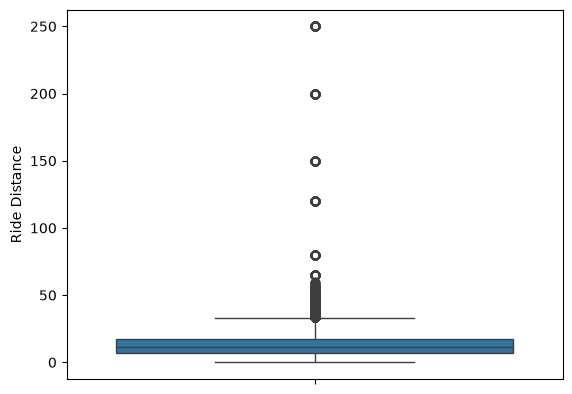

In [392]:
sns.boxplot(df["Ride Distance"])

In [393]:
(df["Ride Distance"] > 100).sum()

np.int64(372)

In [394]:
Q1 = df["Ride Distance"].quantile(0.25)
Q3 = df["Ride Distance"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-9.099999999999998 33.3


In [395]:
df["Ride Distance"] = df["Ride Distance"].clip(upper=upper)

In [396]:
df["Time"].value_counts(dropna=False) 

Time
NaN              2504
Unknown           182
-                 170
Not Available     165
10:37 AM           17
                 ... 
00:59:38            1
22:53:04            1
04:22:48            1
04:58:01            1
18:25:24            1
Name: count, Length: 45218, dtype: int64

In [397]:
df["Time"] = df["Time"].replace({
    "Unknown": np.nan,
    "-": np.nan,
    "Not Available": np.nan
})

In [398]:
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

C:\Users\Admin\AppData\Local\Temp\ipykernel_6336\1188812883.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"], errors="coerce")


In [399]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Reason for cancelling by Customer',
       'Cancelled Rides by Driver', 'Driver Cancellation Reason',
       'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value',
       'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')

In [400]:
df["Hour"] = df["Time"].dt.hour

In [401]:
df["Hour"] = df["Hour"].astype("Int64")

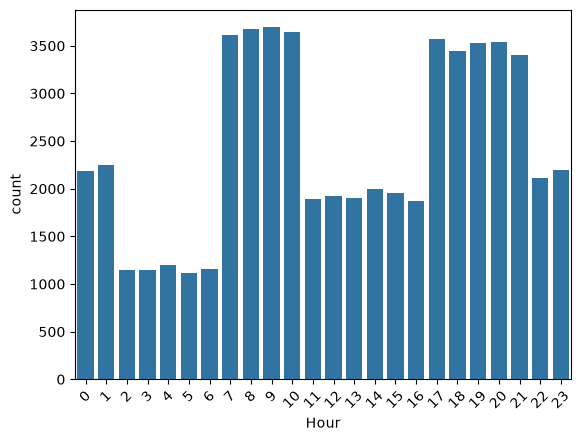

In [452]:
sns.countplot(x=df["Hour"])
plt.xticks(rotation=45)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6336\334353491.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="Vehicle Type",palette='Set3')


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Uber Go'),
  Text(1, 0, 'Uber Auto'),
  Text(2, 0, 'Uber Xl'),
  Text(3, 0, 'Bike'),
  Text(4, 0, 'Uber Premier'),
  Text(5, 0, 'Not Available'),
  Text(6, 0, 'Unknown')])

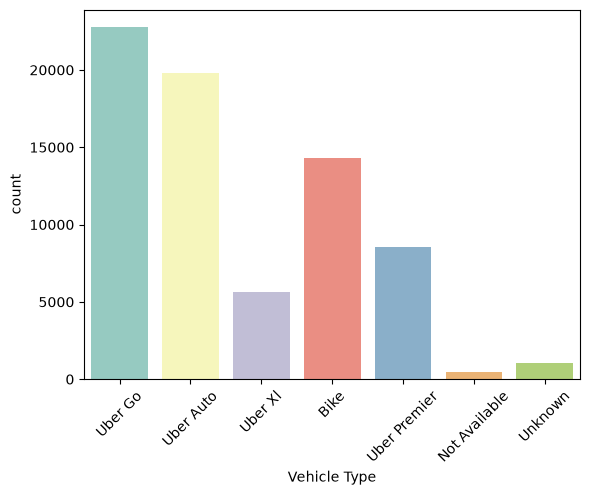

In [ ]:
sns.countplot(data=df,x="Vehicle Type",palette='Set3')
plt.xticks(rotation=45)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6336\2005181764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="Pickup Location",palette='Set3')


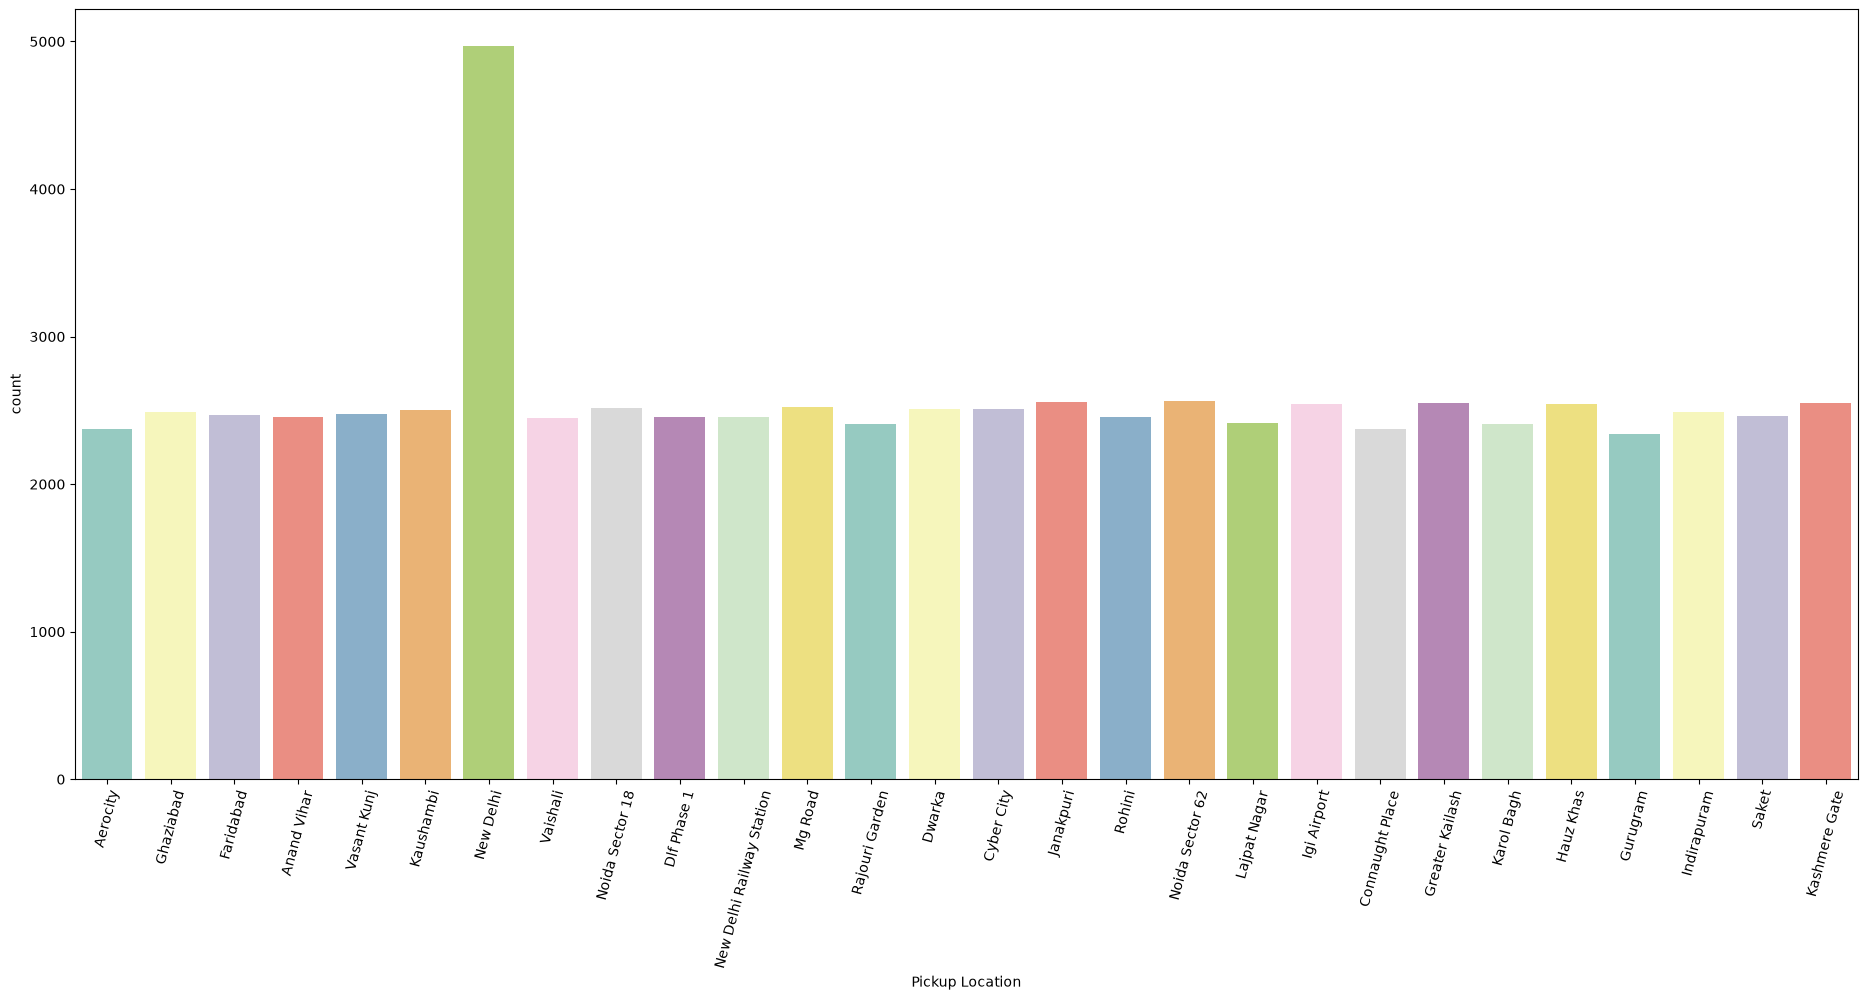

In [404]:
plt.figure(figsize=(23,10))
sns.countplot(data=df,x="Pickup Location",palette='Set3')
plt.xticks(rotation=75)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_6336\3032349760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="Drop Location",palette='Set3')


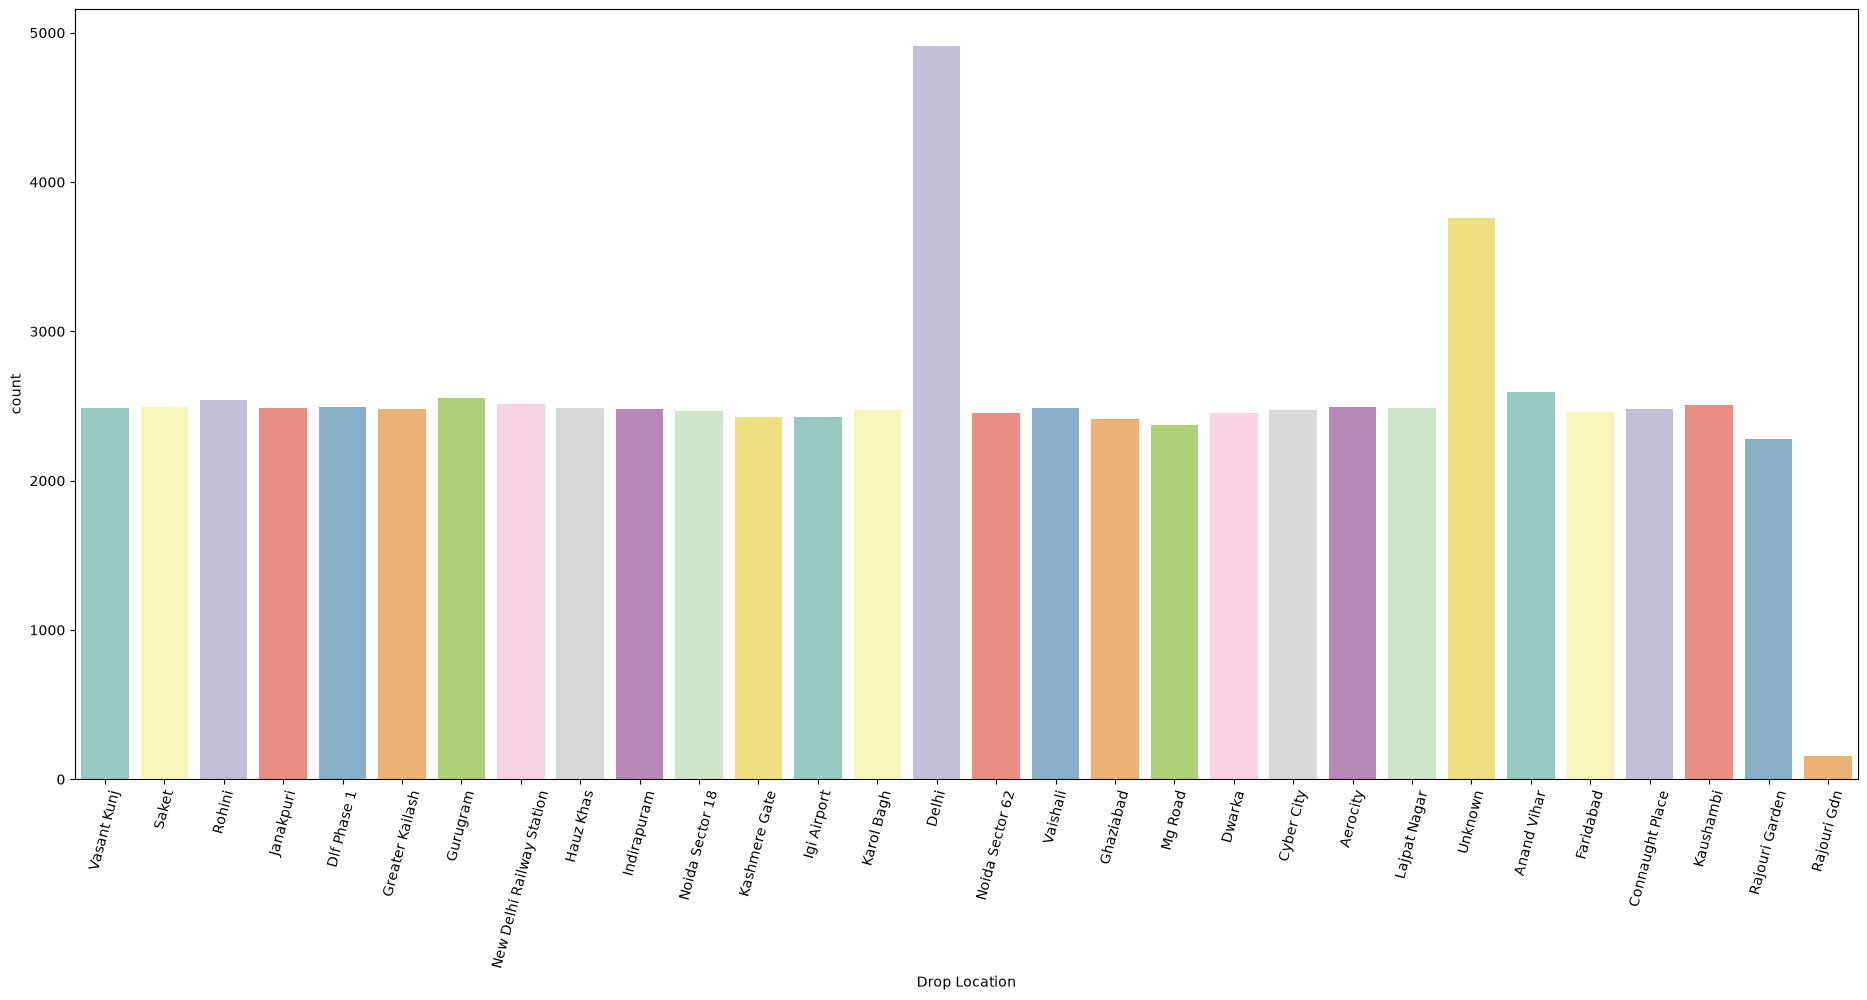

In [405]:
plt.figure(figsize=(23,10))
sns.countplot(data=df,x="Drop Location",palette='Set3')
plt.xticks(rotation=75)
plt.show()


In [406]:
df["Booking Value"].value_counts(dropna=False)

Booking Value
NaN              12138
unknown           1233
Not Available      534
-                  480
Unknown            467
                 ...  
970.3                1
707.7                1
736.7                1
711.8                1
623.7                1
Name: count, Length: 9746, dtype: int64

In [407]:
df["Booking Value"]=df["Booking Value"].str.strip().str.title()

In [408]:


df["Booking Value"] = df["Booking Value"].replace(
    ["Unknown", "Not Available", "-"],
    np.nan
)

In [409]:
df["Booking Value"] = pd.to_numeric(df["Booking Value"], errors="coerce")

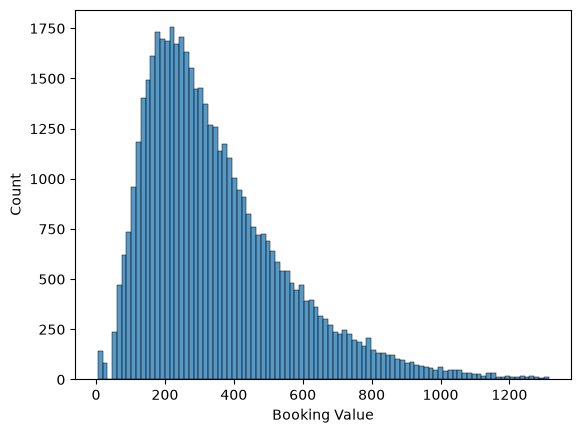

In [467]:
upper = df["Booking Value"].quantile(0.99)

sns.histplot(df[df["Booking Value"] <= upper]["Booking Value"])
plt.show()

In [441]:
df = df[df["Booking Value"] >= 0]

<Figure size 1000x600 with 0 Axes>

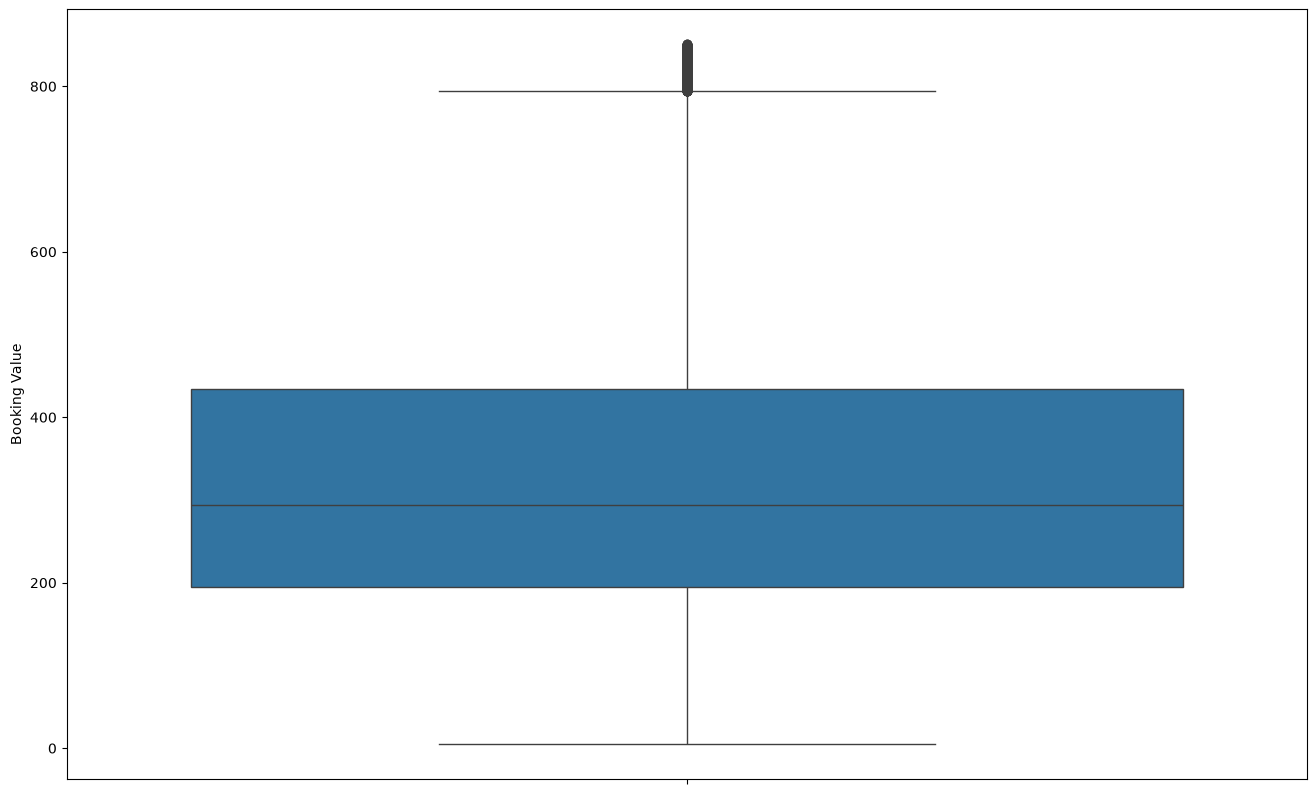

In [446]:
plt.figure(figsize=(10,6))
# sns.boxplot(data=df,x="Booking Value")
Q1 = df["Booking Value"].quantile(0.25)
Q3 = df["Booking Value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

plt.figure(figsize=(16,10))
sns.boxplot(
    y=df[(df["Booking Value"] >= lower) &
         (df["Booking Value"] <= upper)]["Booking Value"]
)
plt.show()

In [423]:
df.loc[df["Driver Cancellation Reason"]=="No reason Provided","Incomplete Rides"].value_counts()

Incomplete Rides
No     59340
Yes     7164
Name: count, dtype: int64

In [412]:
df["Booking Value"].describe()

count    60659.000000
mean       516.749857
std       2256.085809
min      -8000.000000
25%        198.800000
50%        304.000000
75%        459.700000
max      50000.000000
Name: Booking Value, dtype: float64

In [432]:
(df["Booking Value"]>20000).sum()

np.int64(179)

<Axes: xlabel='Ride Distance', ylabel='Count'>

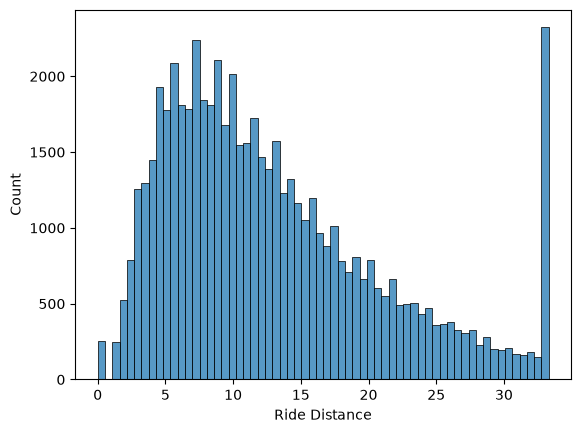

In [413]:
sns.histplot(df["Ride Distance"])

In [414]:
df["Driver Ratings"] = pd.to_numeric(
    df["Driver Ratings"],
    errors="coerce"
)

In [415]:
df["Driver Ratings"] = df["Driver Ratings"].mask(df["Driver Ratings"] < 0)

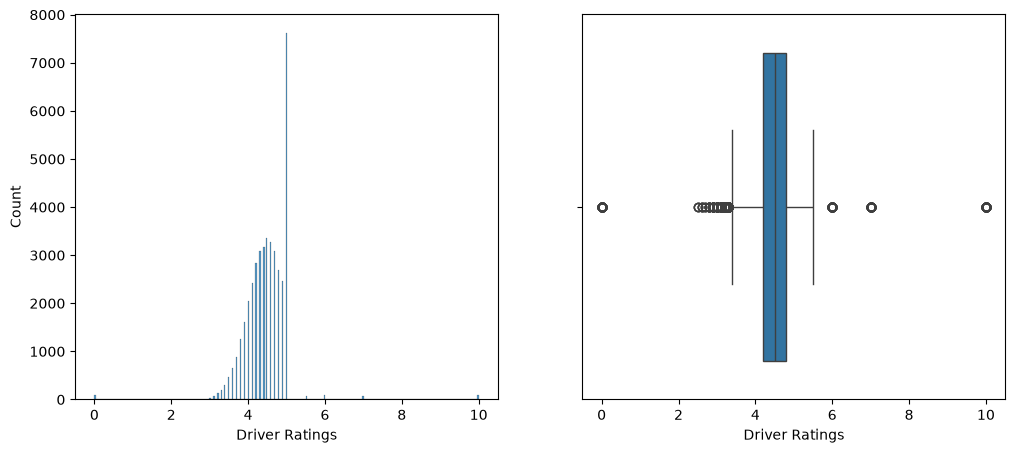

In [416]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.histplot(df["Driver Ratings"])

plt.subplot(1,2,2)
sns.boxplot(x=df["Driver Ratings"])
plt.show()

<Axes: xlabel='count', ylabel='Payment Method'>

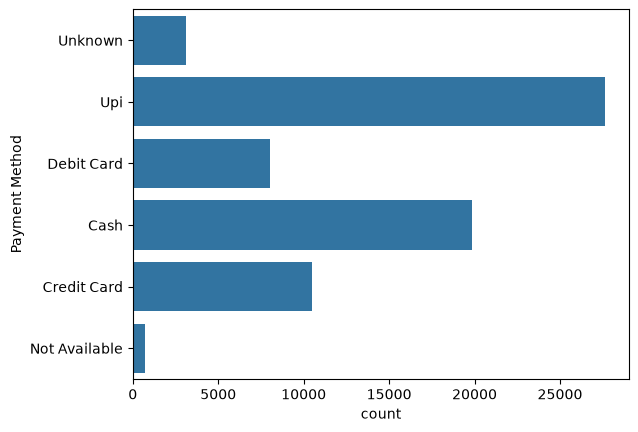

In [417]:
sns.countplot(df["Payment Method"])

<Axes: xlabel='count', ylabel='Cancelled Rides by Driver'>

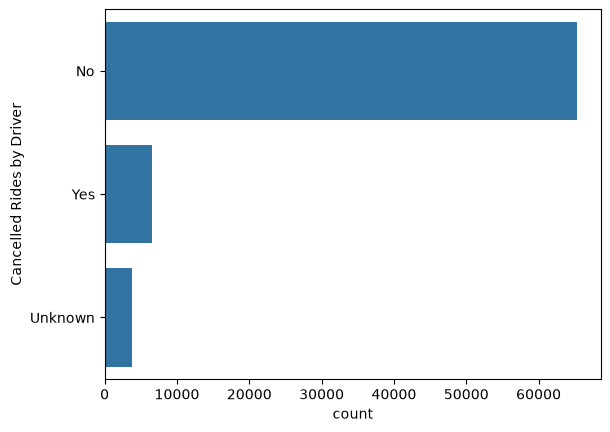

In [ ]:
sns.countplot(df["Cancelled Rides by Driver"])

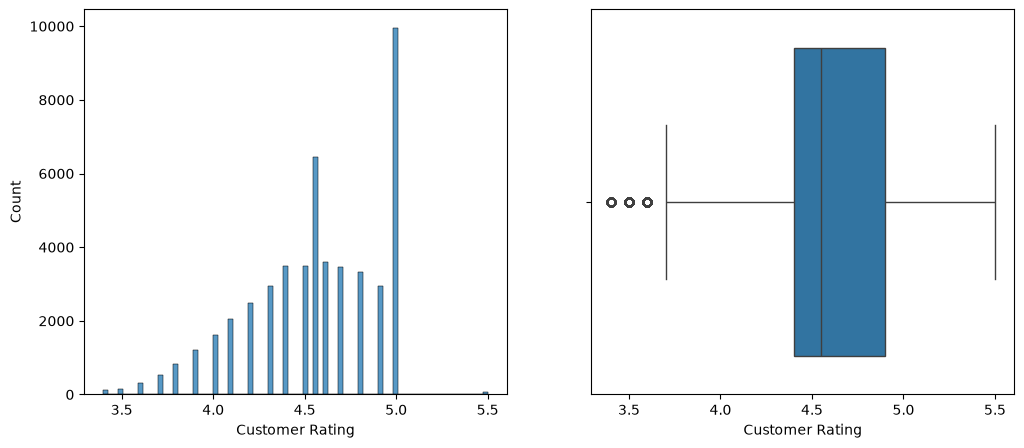

In [457]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.histplot(x=df["Customer Rating"])

plt.subplot(1,2,2)
sns.boxplot(x=df["Customer Rating"])
plt.show()

In [456]:
Q1 = df["Customer Rating"].quantile(0.25)
Q3 = df["Customer Rating"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Customer Rating"] >= lower) & (df["Customer Rating"] <= upper)]

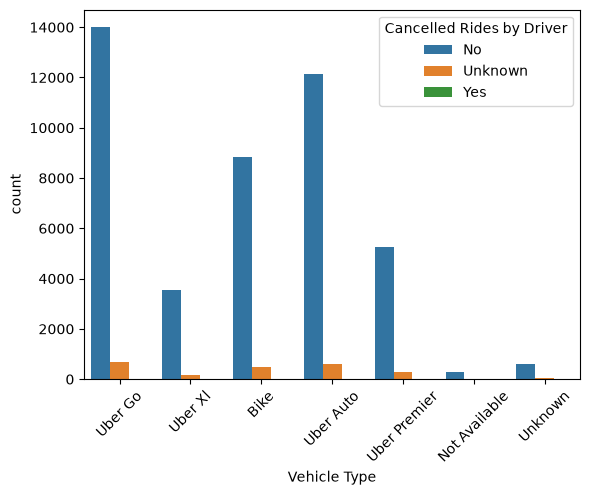

In [465]:

sns.countplot(x="Vehicle Type", hue="Cancelled Rides by Driver", data=df)
plt.xticks(rotation=45)
plt.show()

In [466]:
df["Cancelled Rides by Driver"].value_counts()

Cancelled Rides by Driver
No         46573
Unknown     2430
Yes            6
Name: count, dtype: int64

<Axes: xlabel='Ride Distance', ylabel='Booking Value'>

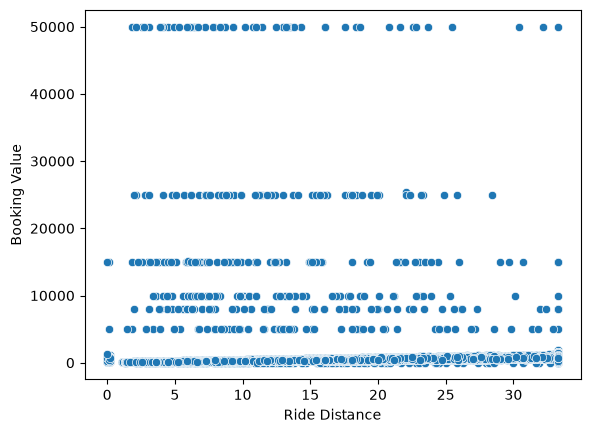

In [460]:
sns.scatterplot(x="Ride Distance", y="Booking Value", data=df)

<Axes: xlabel='Avg VTAT', ylabel='Avg CTAT'>

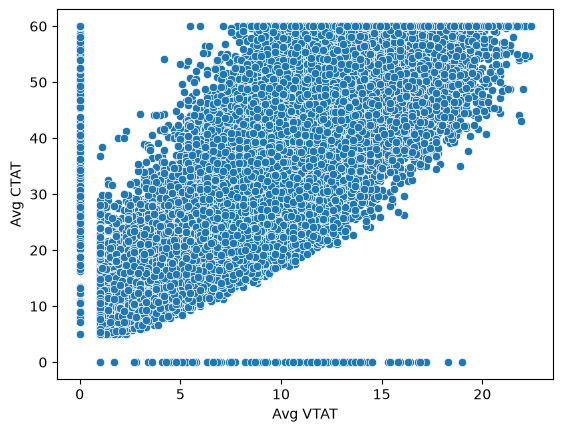

In [461]:
sns.scatterplot(x="Avg VTAT", y="Avg CTAT", data=df)